# Weighted Fields: Velocity and Momentum Density

`Convols` is not limited to the halo number-density field used in the basic examples. Since the coefficient construction starts from

$$
n(\mathbf{x}) = \sum_i w_i \, \delta_\mathrm{D}^{(3)}(\mathbf{x} - \mathbf{x}_i),
$$

changing the particle weights changes the physical field represented by the same wavelet machinery.

This notebook uses the Quijote halo catalog to construct and compare three related fields:

- a halo number-density field $n_h(\mathbf{x})$ from unit weights
- velocity-weighted fields $n_{v_x}(\mathbf{x})$, $n_{v_y}(\mathbf{x})$, and $n_{v_z}(\mathbf{x})$, combined into the velocity field

$$
\mathbf{v}(\mathbf{x}) = \frac{\mathbf{n}_v(\mathbf{x})}{n_h(\mathbf{x})}
$$

- halo momentum-density fields

$$
\mathbf{p}(\mathbf{x}) = \mathbf{n}_{m\mathbf{v}}(\mathbf{x}),
$$

whose divergence is plotted as $(\nabla \cdot \mathbf{p}) / \bar{\rho}_h$

The velocity divergence is closely related to the gravitational potential in linear large-scale structure theory, while the momentum-density field is the quantity that enters line-of-sight momentum observables such as the kinetic Sunyaev-Zel'dovich effect.

## Workflow

1. Build only $n_h$ and $\mathbf{n}_v$, then visualize a random-point two-dimensional velocity slice.
2. Sample the same velocity field on an independent regular grid and compute its divergence and curl.
3. Build $\rho_h$ and $\mathbf{p}$, then compare $\nabla \cdot \mathbf{v}$ with $(\nabla \cdot \mathbf{p}) / \bar{\rho}_h$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyhermes.base.convols import Convols
from pyhermes.io import read_particle_data
from pyhermes.io.window import WindowFunc
from pyhermes.utils.sampling import random_points_box

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

figs_dir = Path("figs")
figs_dir.mkdir(exist_ok=True)


Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


In [2]:
catalog_path = "./data/quijote_halos/8000"
box_size = 1000.0
reader_params = {
    "snapnum": 4,
    "redshift": 0.0,
    "fields": {
        "vx": "vel_x",
        "vy": "vel_y",
        "vz": "vel_z",
        "mass": "mass",
    }
}
halo_data = read_particle_data(catalog_path, data_format="fof", **reader_params)

16:54:13 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
16:54:13 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---


In [3]:
base_params = {
    "box_size": box_size,
    "J": 8,
    "wavelet_mode": "db2",
    "wavelet_level": 10,
    "phi_resolution": 1024,
}
threads = 8

def build_field(pos, weight=None):
    task = Convols({"Convols": base_params})
    task.particle_pos = np.array(pos, copy=True)
    if weight is not None:
        task.particle_weight = np.array(weight, copy=True)
    task.normalize_by_weight_sum = False
    task.threads = threads
    return task.run(save_result=False)

smooth_radius = 10.0
win_tophat = WindowFunc({"type": "sphere", "len_args": {"R": smooth_radius}}, base_params, threads=threads)

count_data = build_field(halo_data["pos"]) @ win_tophat
vx_data = build_field(halo_data["pos"], weight=halo_data["vx"]) @ win_tophat
vy_data = build_field(halo_data["pos"], weight=halo_data["vy"]) @ win_tophat
vz_data = build_field(halo_data["pos"], weight=halo_data["vz"]) @ win_tophat


16:54:13 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:54:13 - INFO - pyhermes.pipeline.pipeline:Convols - Convols runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:54:13 - INFO - pyhermes.pipeline.pipeline:Convols - Preparing Convols input fields ...
16:54:13 - INFO - pyhermes.pipeline.pipeline:Convols - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:54:13 - INFO - pyhermes.pipeline.pipeline:Convols - No particle_weight provided; using unit weights for 406728 particles.
16:54:13 - INFO - pyhermes.pipeline.pipeline:Convols - Input particles ready | source=custom particle_pos array | particle_count=406728 | weight_key=None | weight_sum=4.067280e+05
16:54:13 - INFO - pyhermes.pipeline.pipeline:Convols - Single process mode
16:54:14 - INFO - pyhermes.pipeline.pipeline:Convols - The time for scaling function: 1.0767 sec

16:54:14 - INFO - pyhermes.pipeline.pipeline:Convols - The t

## 1. Random-point velocity slice

The first field construction uses unit weights and velocity weights only. The velocity-weighted fields by themselves have units of number density times velocity, so the velocity field is reconstructed as

$$
\mathbf{v}(\mathbf{x}) = \frac{\mathbf{n}_v(\mathbf{x})}{n_h(\mathbf{x})}.
$$

The slice below is drawn from the random evaluation points already used for the full-box interpolation. This avoids recomputing a special two-dimensional field and shows the same interpolated velocity field used elsewhere in the notebook.


In [4]:
num_random_points = 100_000
random_pos = random_points_box(count=num_random_points, box_size=box_size, seed=42).astype(np.float32)

n_random = count_data.n_at_pos(random_pos)
random_density_floor = 1e-8 * np.nanmax(np.abs(n_random))
valid_random = np.abs(n_random) > random_density_floor
n_valid = n_random[valid_random]

v_at_random = np.full((random_pos.shape[0], 3), np.nan, dtype=np.float64)
for i, vi in enumerate([vx_data, vy_data, vz_data]):
    vi_num = vi.n_at_pos(random_pos)
    vi_num_valid = vi_num[valid_random]
    v_at_random[valid_random, i] = vi_num_valid / n_valid
finite_mask = np.isfinite(v_at_random).all(axis=1)
print(f"Finite velocity points: {finite_mask.sum()} / {random_pos.shape[0]}")

Finite velocity points: 99992 / 100000


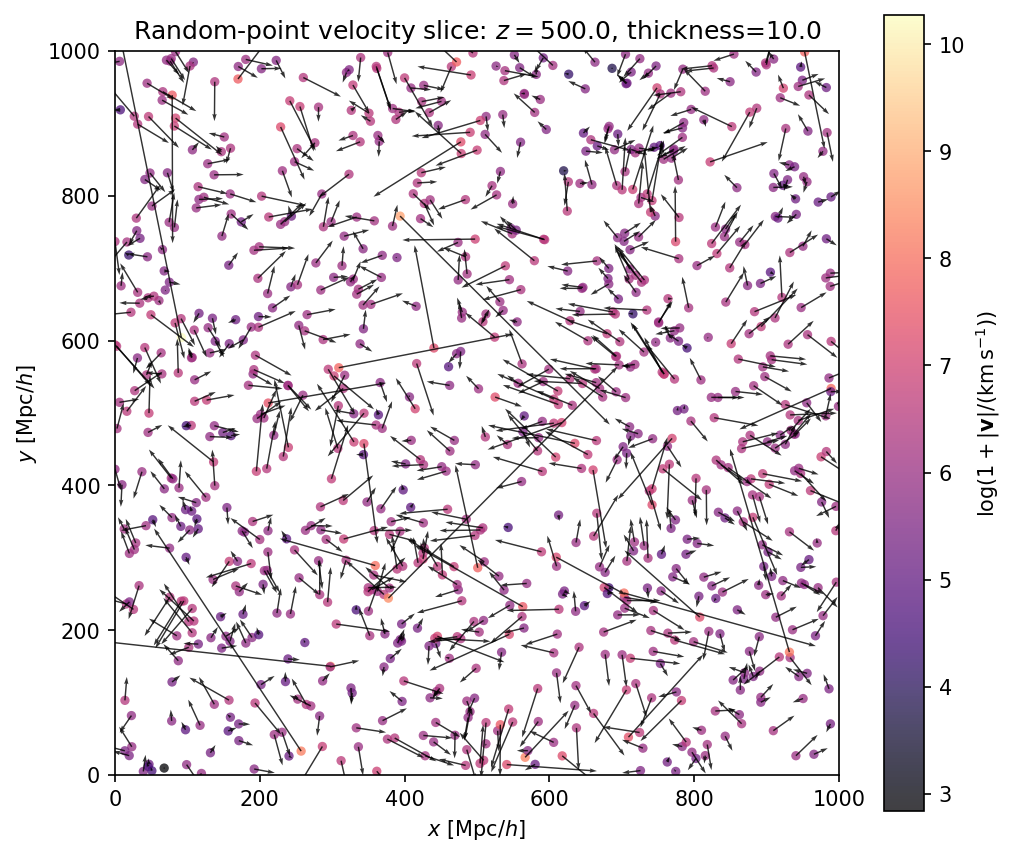

In [5]:
z0 = 500.0
slice_thickness = 10.0

# Periodic distance to the z=z0 plane.
dz_slice = (random_pos[:, 2] - z0 + 0.5 * box_size) % box_size - 0.5 * box_size
slice_mask = np.abs(dz_slice) < 0.5 * slice_thickness

pos2d = random_pos[slice_mask & finite_mask]
vel2d = v_at_random[slice_mask & finite_mask]
vx, vy, vz = vel2d.T
speed = np.sqrt(vx**2 + vy**2 + vz**2)

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

sc = ax.scatter(pos2d[:, 0], pos2d[:, 1], c=np.log1p(speed),
                cmap="magma", s=20, alpha=0.75, linewidths=0)
ax.quiver(pos2d[:, 0], pos2d[:, 1], vx, vy,
          color="k", angles="xy", scale_units="xy", 
          scale=10, width=0.002, alpha=0.8)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\log(1 + |\mathbf{v}| / ({\rm km\,s}^{-1}))$")

ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_aspect("equal")
ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$")
ax.set_ylabel(r"$y\ [{\rm Mpc}/h]$")
ax.set_title(fr"Random-point velocity slice: $z={z0}$, thickness={slice_thickness}")

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_slice.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Regular-grid velocity derivatives

Random points are useful for visualization, but finite-difference derivatives are cleaner on a regular grid. This section samples

$$
\mathbf{v}(\mathbf{x}) = \frac{\mathbf{n}_v(\mathbf{x})}{n_h(\mathbf{x})}
$$

on an independent $128^3$ evaluation grid, then uses periodic central differences to estimate

$$
\nabla \cdot \mathbf{v}, \qquad \nabla \times \mathbf{v}.
$$

Using a grid that is different from the internal PyHermes coefficient grid keeps the derivative estimate simple while still sampling the interpolated field away from only the original coefficient nodes.


In [6]:
def regular_grid_positions(n_grid, box_size, offset=0.5):
    dx = box_size / n_grid
    axis = ((np.arange(n_grid, dtype=np.float32) + offset) * dx) % box_size
    xx, yy, zz = np.meshgrid(axis, axis, axis, indexing="ij")
    pos = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()]).astype(np.float32)
    return pos, dx

def sample_vector_field_grid(component_data_list, box_size, n_grid=128):
    pos, dx = regular_grid_positions(n_grid, box_size)
    components = []
    for component_data in component_data_list:
        values = component_data.n_at_pos(pos)
        components.append(values.reshape((n_grid, n_grid, n_grid)).astype(np.float32))
    return components, dx

def sample_normalized_vector_field_grid(
    normalization_data,
    component_data_list,
    box_size,
    n_grid=128,
    normalization_floor_fraction=1e-12,
):
    pos, dx = regular_grid_positions(n_grid, box_size)
    norm_values = normalization_data.n_at_pos(pos)
    norm_floor = normalization_floor_fraction * np.nanmax(np.abs(norm_values))
    valid = np.abs(norm_values) > norm_floor

    components = []
    for component_data in component_data_list:
        numerator = component_data.n_at_pos(pos)
        component = np.full(norm_values.shape, np.nan, dtype=np.float32)
        np.divide(numerator, norm_values, out=component, where=valid, casting="unsafe")
        components.append(component.reshape((n_grid, n_grid, n_grid)))

    norm_grid = norm_values.reshape((n_grid, n_grid, n_grid)).astype(np.float32)
    valid_grid = valid.reshape((n_grid, n_grid, n_grid))
    return components, valid_grid, norm_grid, dx

def periodic_central_diff(field, axis, spacing):
    return (np.roll(field, -1, axis=axis) - np.roll(field, 1, axis=axis)) / (2.0 * spacing)

def vector_field_divergence(x_component, y_component, z_component, spacing):
    dx_component_dx = periodic_central_diff(x_component, axis=0, spacing=spacing)
    dy_component_dy = periodic_central_diff(y_component, axis=1, spacing=spacing)
    dz_component_dz = periodic_central_diff(z_component, axis=2, spacing=spacing)
    return dx_component_dx + dy_component_dy + dz_component_dz

def vector_field_curl(x_component, y_component, z_component, spacing):
    curl_x = periodic_central_diff(z_component, axis=1, spacing=spacing)
    curl_x -= periodic_central_diff(y_component, axis=2, spacing=spacing)
    curl_y = periodic_central_diff(x_component, axis=2, spacing=spacing)
    curl_y -= periodic_central_diff(z_component, axis=0, spacing=spacing)
    curl_z = periodic_central_diff(y_component, axis=0, spacing=spacing)
    curl_z -= periodic_central_diff(x_component, axis=1, spacing=spacing)
    return curl_x, curl_y, curl_z

def finite_hist_bins(values, percentiles=(1, 99), bins=90):
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError("No finite values available for histogram.")

    lo, hi = np.nanpercentile(values, percentiles)
    if lo == hi:
        pad = 1.0 if lo == 0 else 0.05 * abs(lo)
        lo, hi = lo - pad, hi + pad
    return np.linspace(lo, hi, bins)

In [7]:
n_eval_grid = 128
(vx_grid, vy_grid, vz_grid), valid_v_grid, count_grid, dx = sample_normalized_vector_field_grid(
    count_data,
    [vx_data, vy_data, vz_data],
    box_size,
    n_grid=n_eval_grid,
)
finite_velocity = np.isfinite(vx_grid) & np.isfinite(vy_grid) & np.isfinite(vz_grid)
print("evaluation grid:", f"{n_eval_grid}^3", "dx =", dx, "Mpc/h")
print("valid velocity cells:", finite_velocity.sum(), "/", finite_velocity.size)

evaluation grid: 128^3 dx = 7.8125 Mpc/h
valid velocity cells: 2097152 / 2097152


In [8]:
v_div_grid = vector_field_divergence(vx_grid, vy_grid, vz_grid, spacing=dx)
v_curl_x_grid, v_curl_y_grid, v_curl_z_grid = vector_field_curl(vx_grid, vy_grid, vz_grid, spacing=dx)
v_curl_magnitude_grid = np.sqrt(v_curl_x_grid**2 + v_curl_y_grid**2 + v_curl_z_grid**2)

finite_v_div = np.isfinite(v_div_grid)
finite_v_curl = np.isfinite(v_curl_magnitude_grid)
print("finite velocity divergence cells:", finite_v_div.sum(), "/", v_div_grid.size)
print("finite velocity |curl| cells:", finite_v_curl.sum(), "/", v_curl_magnitude_grid.size)


finite velocity divergence cells: 2097152 / 2097152
finite velocity |curl| cells: 2097152 / 2097152


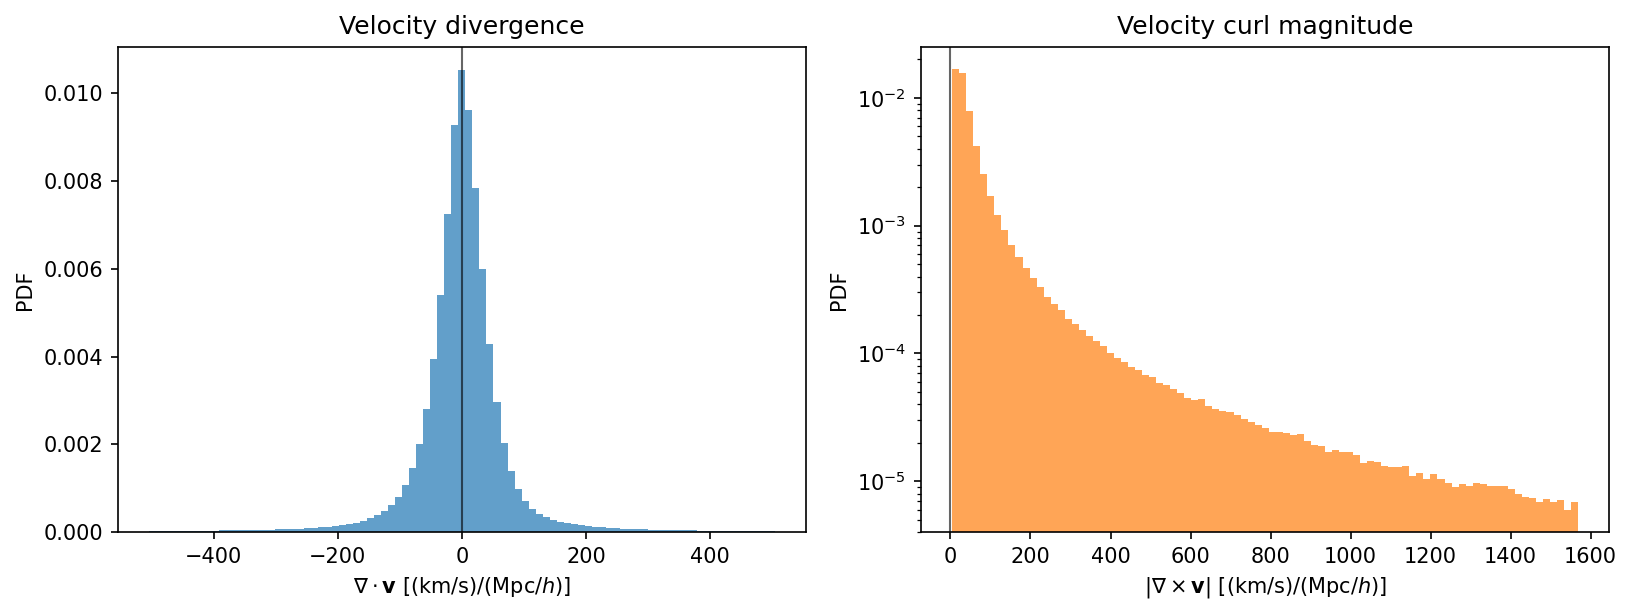

In [9]:
v_div_pdf = v_div_grid[finite_v_div]
v_curl_pdf = v_curl_magnitude_grid[finite_v_curl]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_pdf, v_curl_pdf],
    ["tab:blue", "tab:orange"],
    ["Velocity divergence", "Velocity curl magnitude"],
    [
        r"$\nabla \cdot \mathbf{v}\ [(\mathrm{km}/\mathrm{s})/(\mathrm{Mpc}/h)]$",
        r"$|\nabla \times \mathbf{v}|\ [(\mathrm{km}/\mathrm{s})/(\mathrm{Mpc}/h)]$",
    ],
):
    ax.hist(
        pdf,
        bins=finite_hist_bins(pdf, percentiles=(1, 99), bins=90),
        density=True,
        histtype="stepfilled",
        color=color,
        alpha=0.7,
    )
    ax.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)
    if "curl" in title.lower():
        ax.set_yscale("log")

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_derivatives_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Momentum-density divergence

This section adds mass information. The momentum-density components are built with $m_a v_{a,i}$ weights,

$$
p_i(\mathbf{x}) = \sum_a m_a v_{a,i} W(\mathbf{x} - \mathbf{x}_a),
$$

and are sampled directly on the same regular grid. Unlike the velocity field, this is not divided by the number-density field because the desired quantity is the density-weighted momentum field itself.

For plotting, the divergence is divided by the mean halo mass density,

$$
\frac{\nabla \cdot \mathbf{p}}{\bar{\rho}_h},
$$

so it has the same velocity-per-length units as $\nabla \cdot \mathbf{v}$. The two fields are related, but they are not identical: $\nabla \cdot \mathbf{p}$ also contains density weighting and density-gradient contributions.


In [10]:
px_data = build_field(halo_data["pos"], weight=halo_data["vx"] * halo_data["mass"]) @ win_tophat
py_data = build_field(halo_data["pos"], weight=halo_data["vy"] * halo_data["mass"]) @ win_tophat
pz_data = build_field(halo_data["pos"], weight=halo_data["vz"] * halo_data["mass"]) @ win_tophat

rho_mean = halo_data["mass"].sum() / box_size**3
print("mean halo mass density:", rho_mean, "(Msun/h)/(Mpc/h)^3")

(px_grid, py_grid, pz_grid), dx = sample_vector_field_grid([px_data, py_data, pz_data], box_size, n_grid=n_eval_grid)
p_div_grid = vector_field_divergence(px_grid, py_grid, pz_grid, spacing=dx)

finite_p_div = np.isfinite(p_div_grid)
print("finite momentum divergence cells:", finite_p_div.sum(), "/", p_div_grid.size)


16:54:18 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
16:54:18 - INFO - pyhermes.pipeline.pipeline:Convols - Convols runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:54:18 - INFO - pyhermes.pipeline.pipeline:Convols - Preparing Convols input fields ...
16:54:18 - INFO - pyhermes.pipeline.pipeline:Convols - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
16:54:18 - INFO - pyhermes.pipeline.pipeline:Convols - Input particles ready | source=custom particle_pos array | particle_count=406728 | weight_key=custom | weight_sum=-2.510875e+18
16:54:18 - INFO - pyhermes.pipeline.pipeline:Convols - Single process mode
16:54:19 - INFO - pyhermes.pipeline.pipeline:Convols - The time for scaling function: 0.1985 sec

16:54:19 - INFO - pyhermes.pipeline.pipeline:Convols - The time for task: 0.2056 sec
16:54:19 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ..

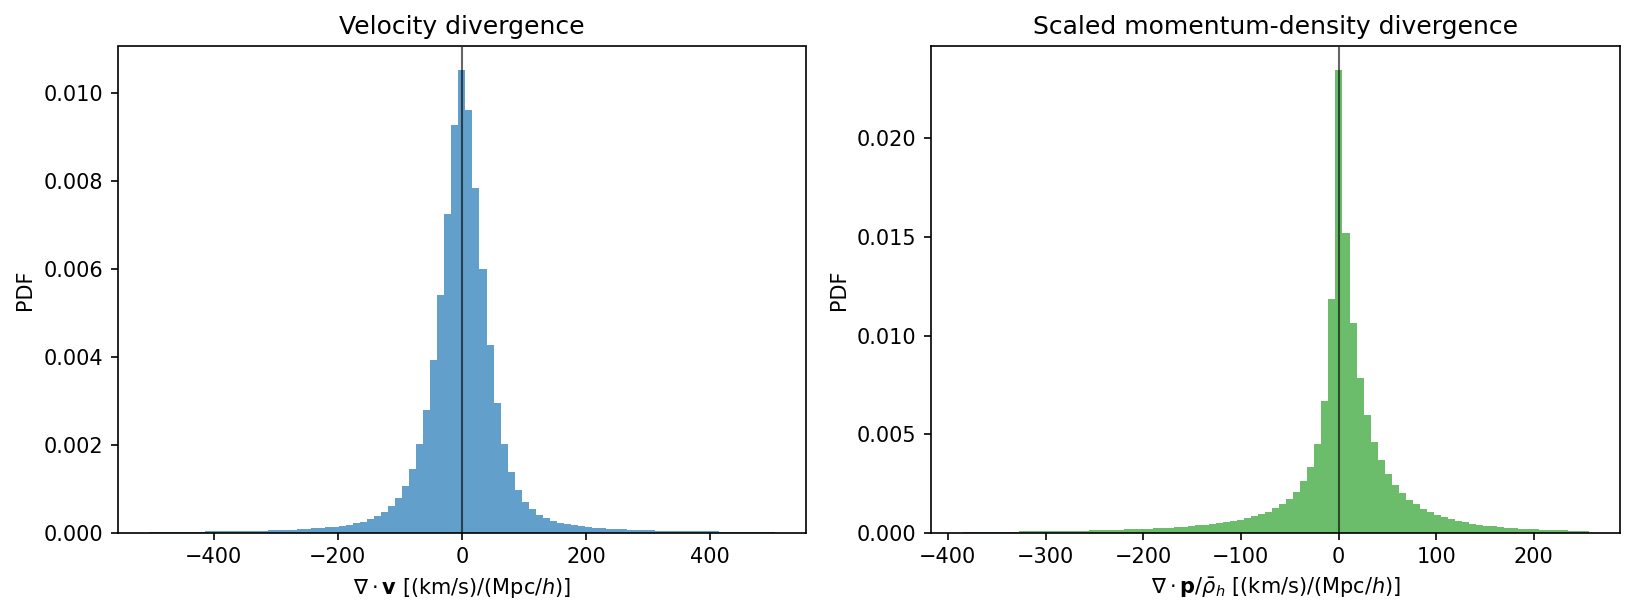

In [11]:
p_div_pdf = p_div_grid[finite_p_div] / rho_mean

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_pdf, p_div_pdf],
    ["tab:blue", "tab:green"],
    ["Velocity divergence", "Scaled momentum-density divergence"],
    [
        r"$\nabla \cdot \mathbf{v}\ [(\mathrm{km}/\mathrm{s})/(\mathrm{Mpc}/h)]$",
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_{h}\ [(\mathrm{km}/\mathrm{s})/(\mathrm{Mpc}/h)]$",
    ],
):
    ax.hist(
        pdf,
        bins=finite_hist_bins(pdf, percentiles=(1, 99), bins=90),
        density=True,
        histtype="stepfilled",
        color=color,
        alpha=0.7,
    )
    ax.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_momentum_divergence_pdf.png", dpi=200, bbox_inches="tight")
plt.show()
